In [16]:
"""
Available models:
- people
- cars
- breasts
Available methods (not for official model):
- aug (for cars and breasts)
- bce
- dice
- mixed (for people)
"""
model = 'cars'
method = 'bce'


In [17]:
import torch
import os
import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from unet import UNet
from scipy.ndimage import binary_dilation, binary_erosion
from predict import predict_img
from torch.utils.data import random_split
from utils.data_loading import BasicDataset

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device: {device}")

target_size = (128, 128)

def calculate_metrics(pred_mask, true_mask):
    pred = (pred_mask > 0).astype(int)
    true = (true_mask > 0).astype(int)
    
    tp = np.sum((pred == 1) & (true == 1))
    tn = np.sum((pred == 0) & (true == 0))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))

    dil = binary_dilation(true == 1)
    ero = binary_erosion(true == 1)
    edge_mask = dil ^ ero

    edge_pixels = edge_mask.sum()
    edge_accuracy = 0
    if edge_pixels > 0:
        pred_on_edge = pred[edge_mask]
        true_on_edge = true[edge_mask]
        edge_TP = int((pred_on_edge & true_on_edge).sum())
        edge_accuracy = edge_TP / edge_pixels
    
    return {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn, 'edge_pixels': edge_pixels, 'edge_accuracy': edge_accuracy, 'total_pixels': pred.size}

def get_validation_files(img_dir, msk_dir, suffix):
    dataset = BasicDataset(img_dir, msk_dir, mask_suffix=suffix)
    n_val = int(len(dataset) * 0.1)
    n_train = len(dataset) - n_val
    _, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))
    return [os.path.join(img_dir, dataset.ids[i] + '.*') for i in val_set.indices]

def evaluate_on_dataset(net, img_dir, msk_dir, files_list, mask_suffix):
    if net is None: return None
    print(f"Evaluating on {len(files_list)} validation images...")
    cum = {'TP': 0, 'FP': 0, 'FN': 0, 'TN': 0, 'edge_pixels': 0, 'edge_accuracy': 0, 'total_pixels': 0}
    
    for img_path_glob in files_list:
        img_path = glob.glob(img_path_glob)[0]
        name = os.path.splitext(os.path.basename(img_path))[0]
        msk_path = os.path.join(msk_dir, name + mask_suffix + '.png')
        if not os.path.exists(msk_path): continue
            
        img = Image.open(img_path).convert('RGB').resize(target_size, Image.Resampling.BILINEAR)
        true_mask = np.asarray(Image.open(msk_path).resize(target_size, Image.Resampling.NEAREST))
        if len(true_mask.shape) == 3: true_mask = true_mask[:,:,0]
        
        pred_mask = predict_img(net, img, device, target_size=128)
        
        m = calculate_metrics(pred_mask, true_mask)
        for k in cum: cum[k] += m[k]

    n = len(files_list)
    correct   = cum['TP'] + cum['TN']
    total     = max(correct + cum['FP'] + cum['FN'], 1)
    precision = cum['TP'] / max(cum['TP'] + cum['FP'], 1)
    recall    = cum['TP'] / max(cum['TP'] + cum['FN'], 1)
    iou       = cum['TP'] / max(cum['TP'] + cum['FP'] + cum['FN'], 1)

    print(f"  Total pixels:     {cum['total_pixels']:,}")
    print(f"  Correct:          {correct:,}  (TP={cum['TP']:,}  TN={cum['TN']:,})")
    print(f"  False positives:  {cum['FP']:,}")
    print(f"  False negatives:  {cum['FN']:,}")
    print(f"  Pixel accuracy:   {correct / total:.2%}")
    print(f"  Precision:        {precision:.2%}")
    print(f"  Recall:           {recall:.2%}")
    print(f"  IoU (Jaccard):    {iou:.2%}")
    print(f"  Edge pixels:      {cum['edge_pixels']:,}")
    print(f"  Edge accuracy:    {cum['edge_accuracy'] / n:.2%}")
    return {'iou': iou * 100, 'precision': precision * 100, 'recall': recall * 100}


Using device: cpu


In [18]:
# Konfiguracja ścieżek i ładowania modelu na podstawie wyboru użytkownika
if model == 'people':
    image_dir = 'Dataset/images/people/'
    mask_dir = 'Dataset/masks/people/'
    mask_suffix = '_mask'
    all_methods = ['bce', 'dice', 'mixed']
    
    def load_selected_model(m_method):
        path = f"Models/people_{m_method}_50.pth"
        if not os.path.exists(path): path = f"Models/people_{m_method}_12.pth"
        net = UNet(n_channels=3, n_classes=2, bilinear=False)
        net.to(device=device)
        state = torch.load(path, map_location=device)
        state.pop('mask_values', None)
        net.load_state_dict(state)
        return net
        
    val_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.png')][:100]

elif model == 'cars':
    image_dir = 'Dataset/images/cars/'
    mask_dir = 'Dataset/masks/cars/'
    mask_suffix = ''
    all_methods = ['bce', 'dice', 'aug']
    
    def load_selected_model(m_method):
        path = f"Models/car_resnet_{m_method}.pth"
        net = smp.Unet('resnet34', encoder_weights=None, in_channels=3, classes=1)
        net.to(device=device)
        state = torch.load(path, map_location=device)
        state.pop('mask_values', None)
        net.load_state_dict(state)
        net.n_classes = 1
        return net
        
    val_files = get_validation_files(image_dir, mask_dir, mask_suffix)

elif model == 'breasts':
    image_dir = 'Dataset/images/breasts/'
    mask_dir = 'Dataset/masks/breasts/'
    mask_suffix = ''
    all_methods = ['bce', 'dice', 'aug']
    
    def load_selected_model(m_method):
        path = f"Models/breast_resnet_{m_method}.pth"
        net = smp.Unet('resnet34', encoder_weights=None, in_channels=3, classes=1)
        net.to(device=device)
        state = torch.load(path, map_location=device)
        state.pop('mask_values', None)
        net.load_state_dict(state)
        net.n_classes = 1
        return net
        
    val_files = get_validation_files(image_dir, mask_dir, mask_suffix)
else:
    raise ValueError("Nieznany model!")

print(f"Dataset config loaded for {model}. Validation files count: {len(val_files)}")


100%|██████████| 780/780 [00:03<00:00, 217.16it/s]

Dataset config loaded for breasts. Validation files count: 78


--- Ewaluacja modelu breasts (Metoda: bce) ---
Evaluating on 78 validation images...
  Total pixels:     1,277,952
  Correct:          1,177,251  (TP=37,168  TN=1,140,083)
  False positives:  29,198
  False negatives:  71,503
  Pixel accuracy:   92.12%
  Precision:        56.00%
  Recall:           34.20%
  IoU (Jaccard):    26.96%
  Edge pixels:      18,093
  Edge accuracy:    14.31%


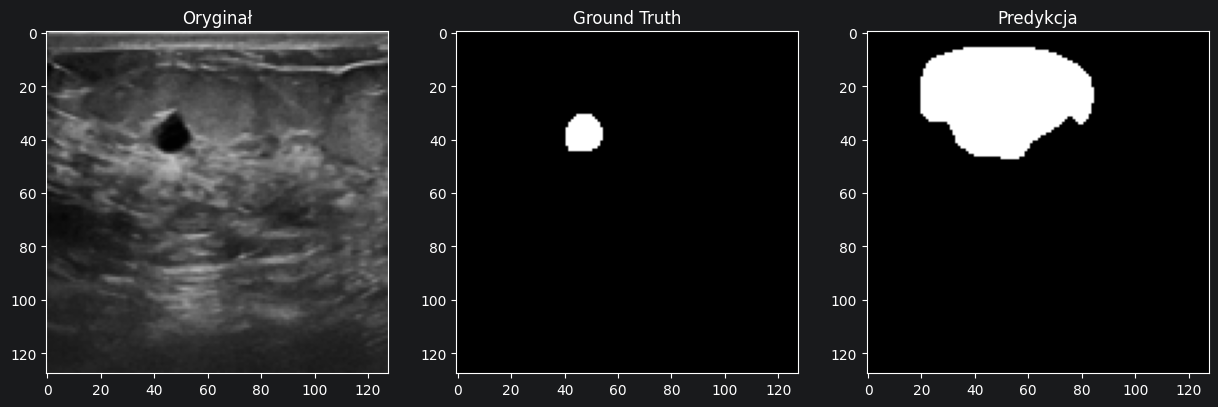

In [19]:
print(f"--- Ewaluacja modelu {model} (Metoda: {method}) ---")
net_current = load_selected_model(method)
metrics_current = evaluate_on_dataset(net_current, image_dir, mask_dir, val_files, mask_suffix)

def visualize_prediction(net, img_path, msk_path):
    if net is None: return
    img = Image.open(img_path).convert('RGB').resize(target_size, Image.Resampling.BILINEAR)
    true_mask = np.asarray(Image.open(msk_path).resize(target_size, Image.Resampling.NEAREST))
    if len(true_mask.shape) == 3: true_mask = true_mask[:,:,0]
    pred_mask = predict_img(net, img, device, target_size=128)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title("Oryginał")
    axes[1].imshow(true_mask > 0, cmap='gray')
    axes[1].set_title("Ground Truth")
    axes[2].imshow(pred_mask > 0, cmap='gray')
    axes[2].set_title("Predykcja")
    plt.show()

if len(val_files) > 0:
    sample_img = glob.glob(val_files[0])[0]
    name = os.path.splitext(os.path.basename(sample_img))[0]
    sample_msk = os.path.join(mask_dir, name + mask_suffix + '.png')
    visualize_prediction(net_current, sample_img, sample_msk)


Porównanie wszystkich metod dla zbioru: breasts
Ładowanie i test bce...
Evaluating on 78 validation images...
  Total pixels:     1,277,952
  Correct:          1,177,251  (TP=37,168  TN=1,140,083)
  False positives:  29,198
  False negatives:  71,503
  Pixel accuracy:   92.12%
  Precision:        56.00%
  Recall:           34.20%
  IoU (Jaccard):    26.96%
  Edge pixels:      18,093
  Edge accuracy:    14.31%
Ładowanie i test dice...
Evaluating on 78 validation images...
  Total pixels:     1,277,952
  Correct:          1,186,517  (TP=44,679  TN=1,141,838)
  False positives:  27,443
  False negatives:  63,992
  Pixel accuracy:   92.85%
  Precision:        61.95%
  Recall:           41.11%
  IoU (Jaccard):    32.82%
  Edge pixels:      18,093
  Edge accuracy:    16.43%
Ładowanie i test aug...
Evaluating on 78 validation images...
  Total pixels:     1,277,952
  Correct:          1,158,147  (TP=59,343  TN=1,098,804)
  False positives:  70,477
  False negatives:  49,328
  Pixel accuracy: 

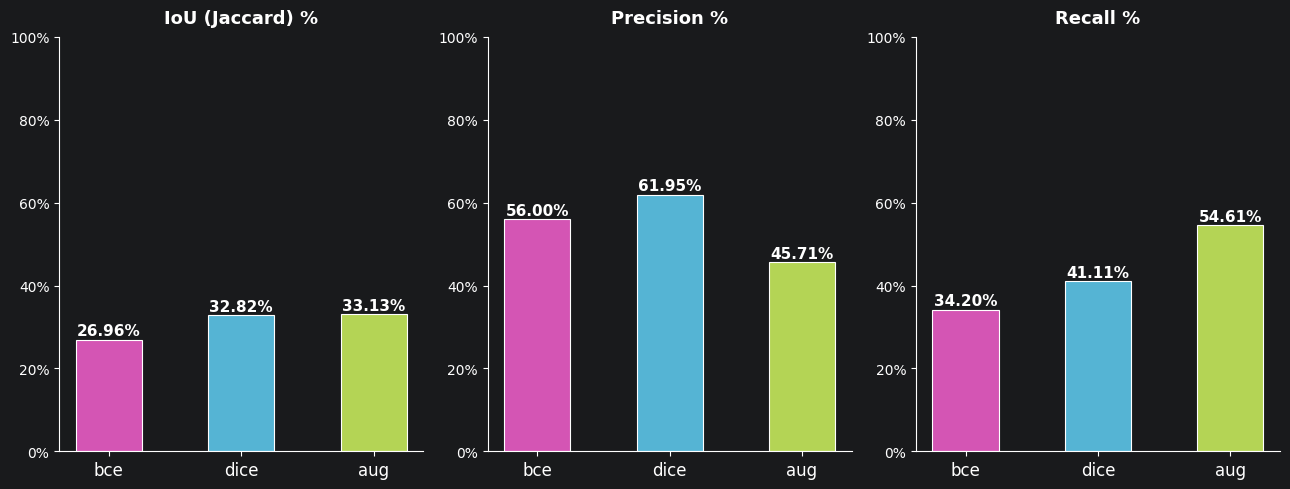

In [20]:
print("" + "="*50)
print(f"Porównanie wszystkich metod dla zbioru: {model}")
print("="*50)

results_all = []
models_names = all_methods

for m_meth in all_methods:
    print(f"Ładowanie i test {m_meth}...")
    tmp_net = load_selected_model(m_meth)
    m_res = evaluate_on_dataset(tmp_net, image_dir, mask_dir, val_files, mask_suffix)
    results_all.append(m_res)

colors = ['#D455B4', '#55B4D4', '#B4D455']
x = np.arange(len(models_names))

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, metric, title, ymin in zip(
    axes,
    ['iou', 'precision', 'recall'],
    ['IoU (Jaccard) %', 'Precision %', 'Recall %'],
    [0, 0, 0],
):
    values = [r[metric] if r else 0 for r in results_all]
    bars = ax.bar(x, values, width=0.5, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models_names, fontsize=12)
    ax.set_ylim(ymin, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
